# Install and import libraries

In [1]:
# pip install --upgrade "jax[cuda]" -f https://storage.googleapis.com/jax-releases/jax_releases.html

In [2]:
import time

import diffrax
import equinox as eqx  # https://github.com/patrick-kidger/equinox
import jax
import jax.nn as jnn
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
import optax  # https://github.com/deepmind/optax
from sklearn.preprocessing import MinMaxScaler
from scipy import interpolate

ERROR:2026-06-16 18:00:40,935:jax._src.xla_bridge:475: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/alkane/miniconda3/envs/node/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 473, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/alkane/miniconda3/envs/node/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/alkane/miniconda3/envs/node/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


# Load dataset

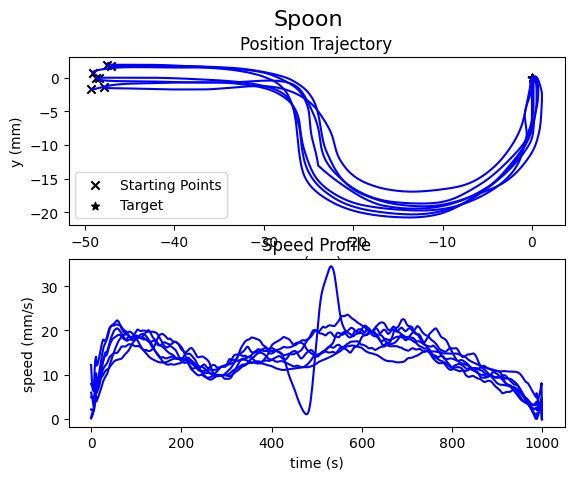

In [3]:
import pyLasaDataset as lasa

# DataSet object has all the LASA handwriting data files
# as attributes, eg:
angle_data = lasa.DataSet.Angle
sine_data = lasa.DataSet.Sine
Leaf_2_data = lasa.DataSet.Leaf_2
CShape_data = lasa.DataSet.CShape
DoubleBendedLine = lasa.DataSet.DoubleBendedLine

data = lasa.DataSet.Spoon


# Each Data object has attributes dt and demos (For documentation,
# refer original dataset repo:
# https://bitbucket.org/khansari/lasahandwritingdataset/src/master/Readme.txt)
dt = data.dt
demos = data.demos # list of 7 Demo objects, each corresponding to a
                         # repetition of the pattern


# Each Demo object in demos list will have attributes pos, t, vel, acc
# corresponding to the original .mat format described in
# https://bitbucket.org/khansari/lasahandwritingdataset/src/master/Readme.txt
demo_0 = demos[1]
pos = demo_0.pos # np.ndarray, shape: (2,2000)
vel = demo_0.vel # np.ndarray, shape: (2,2000)
acc = demo_0.acc # np.ndarray, shape: (2,2000)
t = demo_0.t # np.ndarray, shape: (1,2000)


# To visualise the data (2D position and velocity) use the plot_model utility
lasa.utilities.plot_model(data) # give any of the available
                                                   # pattern data as argument

# Define models

In [4]:
class Func(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        initializer = jnn.initializers.orthogonal()
        self.mlp = eqx.nn.MLP(
            in_size=data_size,
            out_size=data_size,
            width_size=width_size,
            depth=depth,
            activation=jnn.tanh,
            key=key,
        )
        model_key = key
        key_weights = jrandom.split(model_key, depth+1)

        for i in range(depth+1):
          where = lambda m: m.layers[i].weight
          shape = self.mlp.layers[i].weight.shape
          self.mlp = eqx.tree_at(where, self.mlp, replace=initializer(key_weights[i], shape, dtype = jnp.float32))

    @eqx.filter_jit
    def __call__(self, t, y, args):

        return self.mlp(y)

In [5]:
class Funcd(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        initializer = jnn.initializers.orthogonal()
        self.mlp = eqx.nn.MLP(
            in_size=2*data_size,
            out_size=2*data_size,
            width_size=width_size,
            depth=depth,
            activation=jnn.tanh,
            key=key,
        )
        model_key = key
        key_weights = jrandom.split(model_key, depth+1)

        for i in range(depth+1):
          where = lambda m: m.layers[i].weight
          shape = self.mlp.layers[i].weight.shape
          self.mlp = eqx.tree_at(where, self.mlp, replace=initializer(key_weights[i], shape, dtype = jnp.float32))

    @eqx.filter_jit
    def __call__(self, t, yd, args):

        return self.mlp(yd)
        # return self.mlp(jnp.concatenate([yd, jnp.array([t])]))

In [6]:
class NeuralODE(eqx.Module):
    func: Func

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.func = Func(data_size, width_size, depth, key=key)

    def __call__(self, ts, y0):
        solution = diffrax.diffeqsolve(
            diffrax.ODETerm(self.func),
            diffrax.Tsit5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
            saveat=diffrax.SaveAt(ts=ts),
        )
        return solution.ys

In [7]:
class NeuralODEd(eqx.Module):
    func: Funcd

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.func = Funcd(data_size, width_size, depth, key=key)

    @eqx.filter_jit
    def __call__(self, ts, yd0):
        solution = diffrax.diffeqsolve(
            diffrax.ODETerm(self.func),
            diffrax.Tsit5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=yd0,
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
            saveat=diffrax.SaveAt(ts=ts),
        )
        return solution.ys

# Process data. batch_size $\neq$ dataset_size

In [8]:
ndemos = len(demos)
T = demos[0].t.shape[-1]
pos_all = []
vel_all = []
for i in range(ndemos):
  pos_all.append((demos[i].pos).T)
  vel_all.append((demos[i].vel).T)
posn = jnp.array(pos_all)
veln = jnp.array(vel_all)
tn =  jnp.array(t.T).reshape(T)
ys_all_n = jnp.concatenate((posn,veln),axis=2)

In [9]:
nsamples = 1000
ts = t[0]/t[0, -1]
ts_new = jnp.linspace(0, 1, nsamples)

dim = posn.shape[2]

traj_process = jnp.zeros((ndemos, nsamples, dim))
vel_process = jnp.zeros((ndemos, nsamples, dim))

traj_all_t_norm = []
# time_all_process = jnp.zeros((traj_c, nsamples))

seed = 1385

key = jax.random.PRNGKey(seed)
scale_state = 1

key_trajs = jax.random.split(key, num=ndemos)

for i in range(ndemos):
  key_dim = jax.random.split(key_trajs[i], num=dim)
  for j in range(dim):
    f = interpolate.interp1d(ts, posn[i, :, j])
    f_vel = interpolate.interp1d(ts, veln[i, :, j])
    # f = interpolate.interp1d(time_all[i][:, 0], traj_all[i][:, j])
    # ts_new = np.linspace(time_all[i][0, 0], time_all[i][-1, 0], nsamples)
    # time_all_process = time_all_process.at[i].set(ts_new)
    traj_new = f(ts_new)
    vel_new = f_vel(ts_new)
    traj_process = traj_process.at[i, :, j].set(scale_state*traj_new)
    vel_process = vel_process.at[i, :, j].set(scale_state*vel_new)

## Train_Test_split

nTD = 4
traj_train = traj_process[1:nTD]
vel_train = vel_process[1:nTD]

traj_test = traj_process[nTD:]
vel_test = vel_process[nTD:]

## Multi_models

# train_indx = [0, 2, 4, 6]
# nTD = len(train_indx)
# traj_train = jnp.zeros((len(train_indx), nsamples, dim))
# vel_train = jnp.zeros((len(train_indx), nsamples, dim))
# c=0

# for i in train_indx:
#   traj_train = traj_train.at[c].set(traj_process[i])
#   vel_train = vel_train.at[c].set(vel_process[i])
#   c += 1

# test_indx = [1, 3, 5]
# traj_test = jnp.zeros((len(test_indx), nsamples, dim))
# vel_test = jnp.zeros((len(test_indx), nsamples, dim))
# c=0

# for i in test_indx:
#   traj_test = traj_test.at[c].set(traj_process[i])
#   vel_test = vel_test.at[c].set(vel_process[i])
#   c += 1

traj_all_train = jnp.concatenate((traj_train, vel_train), axis=2)
traj_all_test = jnp.concatenate((traj_test, vel_test), axis=2)

# Dataloader

In [10]:
def dataloader(arrays, batch_size, *, key):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = jrandom.permutation(key, indices)
        (key,) = jrandom.split(key, 1)
        start = 0
        end = batch_size
        while end < dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size

# Load the model

In [11]:
file_name = "LASA_models/Spoon_checkpoint.eqx"
# file_name = "/content/drive/MyDrive/Colab Notebooks/Neural ODE/Tunnel_no_d_checkpoint.eqx"
ys = posn
ts = tn
ys_dot = veln
_, length_size, data_size = ys.shape
width_size=128
depth=3
seed=1000
key = jrandom.PRNGKey(seed)
data_key, model_key, loader_key = jrandom.split(key, 3)
model1 = NeuralODE(data_size, width_size, depth, key=model_key)
model = eqx.tree_deserialise_leaves(file_name, model1)
print("done")

done


# Plot obstacles and predicted trajectories

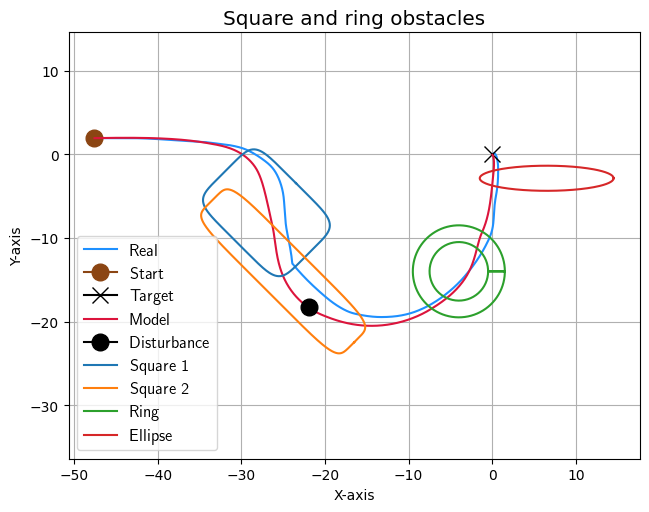

In [12]:
train_indx = 5
plt.plot(posn[train_indx, :, 0], posn[train_indx, :, 1], c="dodgerblue", label="Real")
plt.plot(posn[train_indx, 0, 0], posn[train_indx, 0, 1], c="saddlebrown", marker='o', markersize = '12', label="Start")
plt.plot(posn[train_indx, -1, 0], posn[train_indx, -1, 1], c="black", marker='x', markersize = '12', label="Target")
model_y = model(ts, posn[train_indx, 0])
plt.plot(model_y[:, 0], model_y[:, 1], c="crimson", label="Model")
dist_indx = 500
plt.plot(model_y[dist_indx, 0], model_y[dist_indx, 1], c="black", marker='o', markersize = '12', label="Disturbance")
plt.legend()
plt.tight_layout()
plt.savefig("neural_ode.png")

## Square obstacles (smooth superellipse) + circular obstacle

import matplotlib.pyplot as plt
import numpy as np
import matplotlib

font = {'size':12}
matplotlib.rc('font', **font)
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif"
})

# Superellipse exponent: larger p -> sharper (more square) corners
p_sq = 6

# Square (box) obstacle parameters
center1 = (-27, -7)
semi_major_axis1 = 5
semi_minor_axis1 = 7
angle1 = -np.pi/4   # 大方块: 逆时针旋转45°

center2 = (-25, -14)
semi_major_axis2 = 12   # 小方块: 长度×2 (原为6)
semi_minor_axis2 = 3
angle2 = np.pi/4    # 小方块: 顺时针旋转45°

# Full ring (annulus) obstacle
c = jnp.array([-4, -14]) # Ring center (shifted up)
r_in  = 3.5              # Inner radius
r_out = 5.5              # Outer radius
r = jnp.array([5])       # (kept for reference)

def square_xy(xc, yc, a, b, angle, p=p_sq, n=300):
    """Boundary points of a smooth square (superellipse |.|^p + |.|^p = 1)."""
    th = np.linspace(0, 2*np.pi, n)
    cp = np.sign(np.cos(th)) * np.abs(np.cos(th))**(2.0/p)
    sp = np.sign(np.sin(th)) * np.abs(np.sin(th))**(2.0/p)
    ta, tb = a*cp, b*sp
    xs = xc + np.cos(angle)*ta + np.sin(angle)*tb
    ys = yc - np.sin(angle)*ta + np.cos(angle)*tb
    return xs, ys

x1, y1 = square_xy(center1[0], center1[1], semi_major_axis1, semi_minor_axis1, angle1)
x2, y2 = square_xy(center2[0], center2[1], semi_major_axis2, semi_minor_axis2, angle2)

# Plot the two square obstacles
plt.plot(x1, y1, label='Square 1')
plt.plot(x2, y2, label='Square 2')

# Plot the full ring obstacle
def ring_sector_xy(xc, yc, ri, ro, n=180):
    th = np.linspace(0, 2*np.pi, n)   # full ring
    xo = xc + ro*np.cos(th); yo = yc + ro*np.sin(th)
    xi = xc + ri*np.cos(th[::-1]); yi = yc + ri*np.sin(th[::-1])
    return np.concatenate([xo, xi, xo[:1]]), np.concatenate([yo, yi, yo[:1]])
xr, yr = ring_sector_xy(float(np.asarray(c)[0]), float(np.asarray(c)[1]), r_in, r_out)
plt.plot(xr, yr, label='Ring')

# Ellipse obstacle: thin & long, below target (0,0), top tangent
ae, be = 8.0, 1.5
xe = 6.5
ye = -be * np.sqrt(1.0 - (6.5/ae)**2) - 2.0
_te = np.linspace(0, 2*np.pi, 200)
plt.plot(xe + ae*np.cos(_te), ye + be*np.sin(_te), label='Ellipse')

plt.title('Square and ring obstacles')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid()
plt.axis('equal')
plt.legend()
plt.show()


# CBF-CLF QP implementation

In [13]:
import numpy as np
import cvxpy as cp

indx = train_indx
ys = posn
model_load = model
f = lambda t, z : model_load.func(t, z, _)
xref = model_load(ts, ys[indx, 0, :])
x = posn[indx, 0]
xall = jnp.expand_dims(x, axis=0)
cmd_vel = jnp.array([[0, 0]])

vopt_all = []

dti = ts[1] - ts[0]

## Ellipse parameters

xc1 = center1[0]
yc1 = center1[1]

xc2 = center2[0]
yc2 = center2[1]

a1 = semi_major_axis1
b1 = semi_minor_axis1

a2 = semi_major_axis2
b2 = semi_minor_axis2

r = jnp.array([5]) # (kept for reference)
c = jnp.array([-4, -14]) # Ring center (shifted up)
r_in  = 3.5   # Inner radius of annulus
r_out = 5.5   # Outer radius of annulus
k_ring = 1.5          # soft-min sharpness

# Ellipse obstacle: thin & long, directly below target (0,0); top point tangent to target
ae, be = 8.0, 1.5     # ae = long horizontal semi-axis, be = thin vertical semi-axis
xe = 6.5              # translated left by 1
ye = -be * np.sqrt(1.0 - (6.5/ae)**2) - 2.0  # moved down by 2 (no longer tight against target)

import jax as _jax
from jax.scipy.special import logsumexp as _logsumexp
_cc = jnp.asarray(c).astype(float)
def _ring_barrier(xy):
    dvec = xy - _cc
    dd = jnp.sqrt(dvec @ dvec + 1e-9)
    g_out = r_out - dd                                  # > 0 inside outer circle
    g_in  = dd - r_in                                   # > 0 outside inner circle
    gs = jnp.stack([g_out, g_in])
    return (1.0 / k_ring) * _logsumexp(-k_ring * gs)    # > 0 safe, < 0 inside the ring
_ring_vg = _jax.jit(_jax.value_and_grad(_ring_barrier))

max_steps = 5000        # 最多执行 5000 步
reach_tol = 0.5         # 到达目标的停止阈值 (data 单位)
for i in range(max_steps):

  idx = min(i, len(ts) - 1)  # hold reference at the goal for the extra steps

  # if(i==dist_indx):
  #   # indx = indx_angle
  #   # model_load = model_load_angle
  #   # dist_point = jnp.array([-18, -9])
  #   # dist_point = jnp.array([-50, 15]) # Worm
  #   dist_point = x + jnp.array([0, 10]) # Worm
  #   x = dist_point

  # if(i==600):
  #   indx = indx_spoon
  #   model_load = model_load_spoon
  #   ys = posn_spoon
  #   f = lambda z : model_load.func(_, z, _)

  x_t=np.asarray(x)

  # xref = np.asarray(ys[indx,i,:])

  t0i = 0

  tsi = jnp.array([0, dti])
  # tsi_d = jnp.array([ts[i], ts[i+1]])

  xref_t = np.asarray(xref[idx, :])

  ## Only disturbance

  # alpha_h = 10
  # gamma = 0.1
  # lambda_v = 0

  # Q = np.eye(x_t.shape[0])
  # G = 2*((x_t-xref_t).T)
  # fx_t = np.asarray(f(ts[i], x_t))
  # fxref_t = np.asarray(f(ts[i], xref_t))
  # # h = -2*(((x_t-xref_t).T)@(fx_t - fxref_t)) + alpha_h*(-(((x_t-xref_t).T)@(x_t-xref_t)) + r**2) # CBF
  # h = -2*(((x_t-xref_t).T)@(fx_t - fxref_t)) - alpha_h*((((x_t-xref_t).T)@(x_t-xref_t))) # CLF
  # # h = -(alpha_h*(-(((x1-xref_t).T)@(x1-xref_t)) + r**2) + gamma)

  # # h = alpha_h*(((x1-xref_t).T)@(x1-xref_t))+gamma

  # # h = alpha_h*(-(((x1-xref_t).T)@(x1-xref_t)) + r**2) + gamma

  # vopt = cp.Variable(x_t.shape[0])
  # prob = cp.Problem(cp.Minimize(cp.quad_form(vopt, Q)  + lambda_v*cp.pos(G @ vopt - h)),
  #                 [G @ vopt <= h])

  ## With obstacle

  alpha_L = 4
  alpha_B = 2.3
  lambda_v = 0.1

  Q = np.eye(x_t.shape[0])
  G_L = 2*((x_t-xref_t).T)
  G_B = -2*((x_t-c).T)
  fx_t = np.asarray(f(ts[idx], x_t))
  fxref_t = np.asarray(f(ts[idx], xref_t))
  # h_B = 2*(((x_t-c).T)@(fx_t)) + alpha_B*((((x_t-c).T)@(x_t-c)) - r**2) # CBF
  h_L = -2*(((x_t-xref_t).T)@(fx_t - fxref_t)) - alpha_L*((((x_t-xref_t).T)@(x_t-xref_t))) # CLF
  # h = -(alpha_h*(-(((x1-xref_t).T)@(x1-xref_t)) + r**2) + gamma)

  # h = alpha_h*(((x1-xref_t).T)@(x1-xref_t))+gamma

  # h = alpha_h*(-(((x1-xref_t).T)@(x1-xref_t)) + r**2) + gamma

  # ## Square obstacles (smooth superellipse, p-norm form -> bounded gradients)

  pos_x = x[0]
  pos_y = x[1]

  p_sq = 6        # superellipse exponent (larger -> more square)
  eps_sq = 1e-9   # guards the gradient at the exact center

  # Rotated local coordinates for each square
  ta1 = (pos_x - xc1) * np.cos(angle1) - (pos_y - yc1) * np.sin(angle1)
  tb1 = (pos_x - xc1) * np.sin(angle1) + (pos_y - yc1) * np.cos(angle1)
  ta2 = (pos_x - xc2) * np.cos(angle2) - (pos_y - yc2) * np.sin(angle2)
  tb2 = (pos_x - xc2) * np.sin(angle2) + (pos_y - yc2) * np.cos(angle2)

  # p-norm superellipse: < 0 inside, > 0 outside, grows ~linearly with distance
  S1 = (ta1 / a1)**p_sq + (tb1 / b1)**p_sq + eps_sq
  S2 = (ta2 / a2)**p_sq + (tb2 / b2)**p_sq + eps_sq
  square1_eq = S1**(1.0/p_sq) - 1
  square2_eq = S2**(1.0/p_sq) - 1

  # Gradients of each superellipse (the factor p cancels)
  grad_sq1_x = S1**(1.0/p_sq - 1) * ((ta1/a1)**(p_sq-1)*np.cos(angle1)/a1 + (tb1/b1)**(p_sq-1)*np.sin(angle1)/b1)
  grad_sq1_y = S1**(1.0/p_sq - 1) * (-(ta1/a1)**(p_sq-1)*np.sin(angle1)/a1 + (tb1/b1)**(p_sq-1)*np.cos(angle1)/b1)
  grad_sq2_x = S2**(1.0/p_sq - 1) * ((ta2/a2)**(p_sq-1)*np.cos(angle2)/a2 + (tb2/b2)**(p_sq-1)*np.sin(angle2)/b2)
  grad_sq2_y = S2**(1.0/p_sq - 1) * (-(ta2/a2)**(p_sq-1)*np.sin(angle2)/a2 + (tb2/b2)**(p_sq-1)*np.cos(angle2)/b2)

  # Product barrier: outer boundary of the two square obstacles
  B = square1_eq * square2_eq
  grad_B_x = grad_sq1_x * square2_eq + square1_eq * grad_sq2_x
  grad_B_y = grad_sq1_y * square2_eq + square1_eq * grad_sq2_y

  grad_B = jnp.array([[grad_B_x, grad_B_y]])

  ## Full ring (annulus) obstacle.
  ## Smooth soft-min barrier over {inside outer} AND {outside inner};
  ## gradient via autodiff. B_c/grad_B_c names kept so the CBF constraint is unchanged.
  _Bv, _gv = _ring_vg(jnp.asarray(x_t, dtype=float))
  B_c = np.asarray(_Bv)
  grad_B_c = np.asarray(_gv)

  alpha_B_c = 10

  ## Ellipse obstacle (closed-form quadratic): > 0 outside (safe), < 0 inside
  B_e = ((x_t[0] - xe)/ae)**2 + ((x_t[1] - ye)/be)**2 - 1.0
  grad_B_e = np.array([[2*(x_t[0] - xe)/ae**2, 2*(x_t[1] - ye)/be**2]])
  alpha_B_e = 2.3

  vopt = cp.Variable(x_t.shape[0])
  epsilon = cp.Variable((1,1))
  prob = cp.Problem(cp.Minimize(cp.quad_form(vopt, Q)  + lambda_v*cp.quad_form(epsilon, np.eye(1))),
                  [G_L @ vopt - epsilon <= h_L,
                   grad_B @ (fx_t + vopt) >= -alpha_B * B,
                   grad_B_c @ (fx_t + vopt) >= -alpha_B_c * B_c,
                   grad_B_e @ (fx_t + vopt) >= -alpha_B_e * B_e])

  prob.solve()

  f1 = lambda z : model_load.func(_, z,_) + vopt.value

  ## Circular obstacle

  # vopt = cp.Variable(x_t.shape[0])
  # epsilon = cp.Variable((1,1))
  # prob = cp.Problem(cp.Minimize(cp.quad_form(vopt, Q)  + lambda_v*cp.quad_form(epsilon, np.eye(1))),
  #                 [G_L @ vopt - epsilon <= h_L,
  #                  G_B @ vopt <= h_B])

  # prob.solve()

  # f1 = lambda z : model_load.func(_, z,_) + vopt.value

  ## Switching mode

  # f1 = lambda z : model_load.func(_, z,_)

  # x = jnp.asarray(x1)

  # f1 = lambda t, z, args : model_load.func(t, z, _) + vopt.value
  # solution = diffrax.diffeqsolve(
  #     diffrax.ODETerm(f1),
  #     diffrax.Tsit5(),
  #     t0=ts[i],
  #     t1=ts[i+1],
  #     dt0=dti,
  #     y0=x,
  #     stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
  #     saveat=diffrax.SaveAt(ts=tsi_d),
  # )

  vopt_all.append(np.linalg.norm(vopt.value))

  xnext = f1(x)*dti + x

  # xnext = solution.ys[-1,:]

  xall = jnp.append(xall, jnp.expand_dims(xnext, axis=0), axis=0)

  cmd_vel = jnp.append(cmd_vel, jnp.expand_dims(f1(x), axis=0), axis=0)

  x = xnext

  if(i%10==0):
    print(f"Time: {i}, Position: {x}")

  # 提前到达目标则停止,否则继续直到 max_steps
  _dist_goal = float(np.linalg.norm(np.asarray(x) - np.asarray(xref[-1])))
  if _dist_goal < reach_tol:
    print(f"Reached target at step {i} (dist {_dist_goal:.4f}); stopping early")
    break

Polishing not needed - no active set detected at optimal point
Time: 0, Position: [-47.474228    1.9245232]


Time: 10, Position: [-46.692123   1.937763]
Time: 20, Position: [-45.91022     1.9485606]


Time: 30, Position: [-45.128567    1.9565637]


Time: 40, Position: [-44.347202    1.9613568]
Time: 50, Position: [-43.5662      1.9624518]


Time: 60, Position: [-42.785645    1.9592772]
Time: 70, Position: [-42.00563     1.9511671]


...

Time: 4950, Position: [-0.8483181 -3.467436 ]


Time: 4960, Position: [-0.8483181 -3.467436 ]


Time: 4970, Position: [-0.8483181 -3.467436 ]


Time: 4980, Position: [-0.8483181 -3.467436 ]


Time: 4990, Position: [-0.8483181 -3.467436 ]


In [14]:
# import sympy as sym

# pos_x, pos_y, xc1, yc1, a1, b1, angle1, xc2, yc2, a2, b2, angle2 = sym.symbols('pos_x pos_y xc1 yc1 a1 b1 angle1 xc2 yc2 a2 b2 angle2')

# # Define the equation of the tilted ellipse
# ellipse_eq = ((((pos_x - xc1)*sym.cos(angle1) + (pos_y-yc1)*sym.sin(angle1))**2 / a1**2) + (-((pos_x - xc1)*sym.sin(angle1) + (pos_y-yc1)*sym.cos(angle1))**2 / b1**2) - 1) * ((((pos_x - xc2)*sym.cos(angle2) + (pos_y-yc2)*sym.sin(angle2))**2 / a2**2) + (-((pos_x - xc2)*sym.sin(angle2) + (pos_y-yc2)*sym.cos(angle2))**2 / b2**2) - 1) # Compute the gradient
# gradient = [sym.diff(ellipse_eq, var) for var in (pos_x, pos_y)]

# print("Gradient components with respect to x and y:")
# print(gradient[0])
# print(gradient[1])

# Plot implemented trajectories

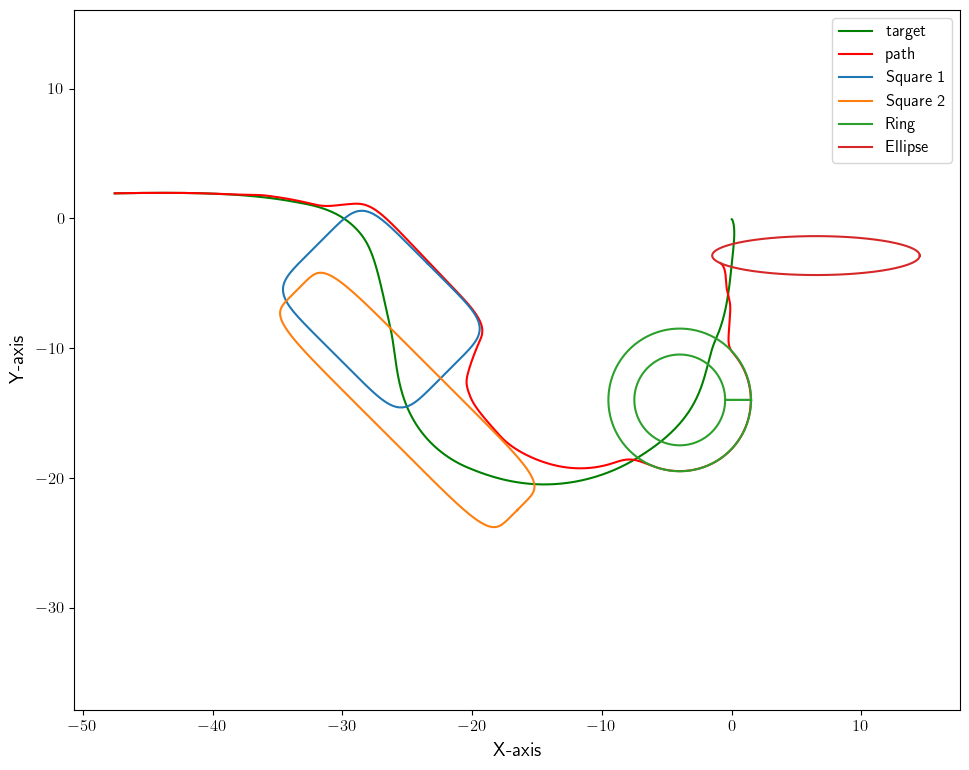

In [15]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(xref[:, 0], xref[:, 1], label='target', color='green')
ax.plot(xall[:, 0], xall[:, 1], label='path', color='red')

# ---- Square obstacle parameters (match the CBF) ----
p_sq = 6
center1 = (-27, -7)
a1, b1, angle1 = 5, 7, -np.pi/4   # 大方块逆时针45°

center2 = (-25, -14)
a2, b2, angle2 = 12, 3, np.pi/4    # 小方块长度×2 + 顺时针45°

def square_xy(xc, yc, a, b, angle, p=p_sq, n=300):
    th = np.linspace(0, 2*np.pi, n)
    cp = np.sign(np.cos(th)) * np.abs(np.cos(th))**(2.0/p)
    sp = np.sign(np.sin(th)) * np.abs(np.sin(th))**(2.0/p)
    ta, tb = a*cp, b*sp
    xs = xc + np.cos(angle)*ta + np.sin(angle)*tb
    ys = yc - np.sin(angle)*ta + np.cos(angle)*tb
    return xs, ys

x1, y1 = square_xy(center1[0], center1[1], a1, b1, angle1)
x2, y2 = square_xy(center2[0], center2[1], a2, b2, angle2)

ax.plot(x1, y1, label='Square 1')
ax.plot(x2, y2, label='Square 2')

# ---- Full ring (annulus) obstacle ----
cc = np.asarray(c)
th = np.linspace(0, 2*np.pi, 180)
xo = cc[0] + r_out*np.cos(th); yo = cc[1] + r_out*np.sin(th)
xi = cc[0] + r_in*np.cos(th[::-1]); yi = cc[1] + r_in*np.sin(th[::-1])
ax.plot(np.concatenate([xo, xi, xo[:1]]), np.concatenate([yo, yi, yo[:1]]), label='Ring')

# Ellipse obstacle below target (top tangent to (0,0))
_te = np.linspace(0, 2*np.pi, 200)
ax.plot(xe + ae*np.cos(_te), ye + be*np.sin(_te), label='Ellipse')

# ---- formatting ----
ax.set_xlabel('X-axis', fontsize=14, labelpad=6)
ax.set_ylabel('Y-axis', fontsize=14, labelpad=6)
ax.tick_params(labelsize=12)
ax.legend()
ax.axis('equal')

fig.tight_layout(pad=1.5)
plt.show()


# Plot with vector field

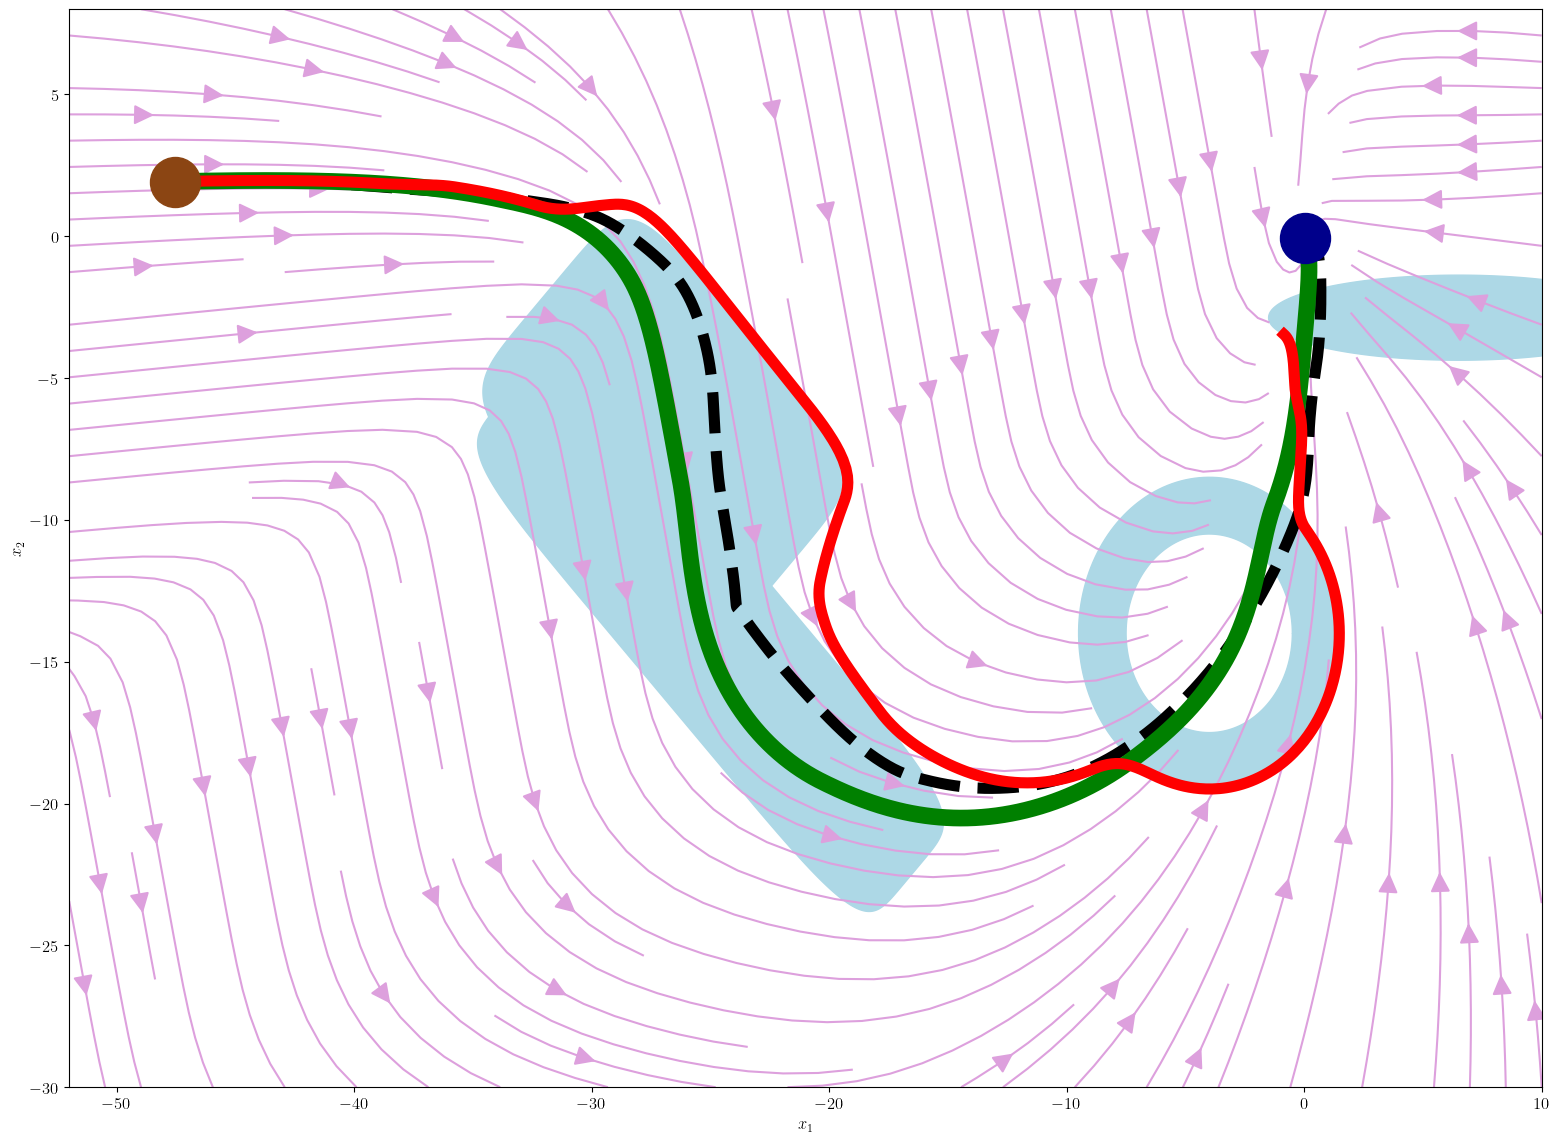

In [16]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

def streamQuiver(ax,sp,*args,spacing=None,n=5,**kwargs):
    """ Plot arrows from streamplot data
    The number of arrows per streamline is controlled either by `spacing` or by `n`.
    See `lines_to_arrows`.
    """
    def curve_coord(line=None):
        """ return curvilinear coordinate """
        x=line[:,0]
        y=line[:,1]
        s     = np.zeros(x.shape)
        s[1:] = np.sqrt((x[1:]-x[0:-1])**2+ (y[1:]-y[0:-1])**2)
        s     = np.cumsum(s)
        return s

    def curve_extract(line,spacing,offset=None):
        """ Extract points at equidistant space along a curve"""
        x=line[:,0]
        y=line[:,1]
        if offset is None:
            offset=spacing/2
        # Computing curvilinear length
        s = curve_coord(line)
        offset=np.mod(offset,s[-1]) # making sure we always get one point
        # New (equidistant) curvilinear coordinate
        sExtract=np.arange(offset,s[-1],spacing)
        # Interpolating based on new curvilinear coordinate
        xx=np.interp(sExtract,s,x);
        yy=np.interp(sExtract,s,y);
        return np.array([xx,yy]).T

    def seg_to_lines(seg):
        """ Convert a list of segments to a list of lines """
        def extract_continuous(i):
            x=[]
            y=[]
            # Special case, we have only 1 segment remaining:
            if i==len(seg)-1:
                x.append(seg[i][0,0])
                y.append(seg[i][0,1])
                x.append(seg[i][1,0])
                y.append(seg[i][1,1])
                return i,x,y
            # Looping on continuous segment
            while i<len(seg)-1:
                # Adding our start point
                x.append(seg[i][0,0])
                y.append(seg[i][0,1])
                # Checking whether next segment continues our line
                Continuous= all(seg[i][1,:]==seg[i+1][0,:])
                if not Continuous:
                    # We add our end point then
                    x.append(seg[i][1,0])
                    y.append(seg[i][1,1])
                    break
                elif i==len(seg)-2:
                    # we add the last segment
                    x.append(seg[i+1][0,0])
                    y.append(seg[i+1][0,1])
                    x.append(seg[i+1][1,0])
                    y.append(seg[i+1][1,1])
                i=i+1
            return i,x,y
        lines=[]
        i=0
        while i<len(seg):
            iEnd,x,y=extract_continuous(i)
            lines.append(np.array( [x,y] ).T)
            i=iEnd+1
        return lines

    def lines_to_arrows(lines,n=5,spacing=None,normalize=True):
        """ Extract "streamlines" arrows from a set of lines
        Either: `n` arrows per line
            or an arrow every `spacing` distance
        If `normalize` is true, the arrows have a unit length
        """
        if spacing is None:
            # if n is provided we estimate the spacing based on each curve lenght)
            spacing = [ curve_coord(l)[-1]/n for l in lines]
        try:
            len(spacing)
        except:
            spacing=[spacing]*len(lines)

        lines_s=[curve_extract(l,spacing=sp,offset=sp/2)         for l,sp in zip(lines,spacing)]
        lines_e=[curve_extract(l,spacing=sp,offset=sp/2+0.01*sp) for l,sp in zip(lines,spacing)]
        arrow_x  = [l[i,0] for l in lines_s for i in range(len(l))]
        arrow_y  = [l[i,1] for l in lines_s for i in range(len(l))]
        arrow_dx = [le[i,0]-ls[i,0] for ls,le in zip(lines_s,lines_e) for i in range(len(ls))]
        arrow_dy = [le[i,1]-ls[i,1] for ls,le in zip(lines_s,lines_e) for i in range(len(ls))]

        if normalize:
            dn = [ np.sqrt(ddx**2 + ddy**2) for ddx,ddy in zip(arrow_dx,arrow_dy)]
            arrow_dx = [ddx/ddn for ddx,ddn in zip(arrow_dx,dn)]
            arrow_dy = [ddy/ddn for ddy,ddn in zip(arrow_dy,dn)]
        return  arrow_x,arrow_y,arrow_dx,arrow_dy

    # --- Main body of streamQuiver
    # Extracting lines
    seg   = sp.lines.get_segments() # list of (2, 2) numpy arrays
    lines = seg_to_lines(seg)       # list of (N,2) numpy arrays
    # Convert lines to arrows
    ar_x, ar_y, ar_dx, ar_dy = lines_to_arrows(lines,spacing=spacing,n=n,normalize=True)
    # Plot arrows
    qv=ax.quiver(ar_x, ar_y, ar_dx, ar_dy, *args, angles='xy', **kwargs)
    return qv

## Worm
# xmin = -60
# xmax = 5
# ymin = -7
# ymax = 20

## Spoon
xmin = -52
xmax = 10
ymin = -30
ymax = 8

## Sine
# xmin = -60
# xmax = 10
# ymin = -20
# ymax = 30

indx = train_indx

f = lambda z : model.func(_, z, _)

(fig, ax) = plt.subplots(nrows=1, ncols=1, figsize=(19,14))
x, y = np.meshgrid(np.linspace(xmin, xmax, 50),
                   np.linspace(ymin, ymax, 50))
xy_vec = np.hstack((x.reshape((x.size, -1)), y.reshape((y.size, -1))))
uv_vec = jax.vmap(f, in_axes=0)(xy_vec)
proj_uv = uv_vec
u = np.asarray(proj_uv[:, 0]).reshape(x.shape)
v = np.asarray(proj_uv[:, 1]).reshape(y.shape)
sp = ax.streamplot(x, y, u ,v, arrowsize = 3, density=1.4, color='plum') #, arrowstyle='->', density=1, arrowsize=0.1)
# streamQuiver(ax, sp, n=10, color='plum', width = 0.01)
# fig = go.Figure()
model_y = model(ts, ys[indx, 0])
g_indx = -1
# ax.annotate('Start', xy=(model_y[0, 0], model_y[0, 1]), xytext=(-50, 25), textcoords='offset points', bbox=dict(boxstyle="round", fc="0.9", alpha=0.6))
# ax.annotate('Goal', xy=(model_y[g_indx, 0], model_y[g_indx, 1]), xytext=(-30, 0), textcoords='offset points', horizontalalignment='right', bbox=dict(boxstyle="round", fc="0.9", alpha=0.6))
## Switch mode
ax.plot(posn[indx, :, 0], posn[indx, :, 1], c="black", linestyle='--', linewidth='8', label="Demonstration")
ax.plot(model_y[:, 0], model_y[:, 1], c="green", linewidth='12', label="Target trajectory")
# model_y_1 = model(ts, posn[indx, 0])
# ax.plot(model_y_1[ :, 0], model_y_1[ :, 1], c="green", linewidth='3')
# switch_indx = 2
# model_y_2 = model(ts, posn[switch_indx, 0])
# ax.plot(model_y_2[ :, 0], model_y_2[ :, 1], c="green", linewidth='3')
# ax.plot(posn[switch_indx, :, 0], posn[switch_indx, :, 1], c="black", linestyle='--', linewidth='3')
# # ax.annotate('Switch mode', xy=(dist_point[0], dist_point[1]), xytext=(-10, -30), textcoords='offset points', horizontalalignment='right', bbox=dict(boxstyle="round", fc="0.9", alpha=0.6))
# ax.annotate("", xy=(dist_point[0], dist_point[1]), xytext=(model_y[dist_indx, 0], model_y[dist_indx, 1]),
#             arrowprops=dict(mutation_scale=30, arrowstyle="->", linewidth=3)) # Arrow


ax.plot(xall[:, 0], xall[:, 1], c="red", linewidth='8', label="Motion plan")

ax.plot(model_y[0, 0], model_y[0, 1], marker="o", markersize=36, c="saddlebrown")
ax.plot(model_y[-1, 0], model_y[-1, 1], marker="o", markersize=36, c="darkblue")

# Square obstacle boundaries (smooth superellipse)
def square_xy(xc, yc, a, b, angle, p=p_sq, n=300):
    th = np.linspace(0, 2*np.pi, n)
    cp = np.sign(np.cos(th)) * np.abs(np.cos(th))**(2.0/p)
    sp = np.sign(np.sin(th)) * np.abs(np.sin(th))**(2.0/p)
    ta, tb = a*cp, b*sp
    xs = xc + np.cos(angle)*ta + np.sin(angle)*tb
    ys = yc - np.sin(angle)*ta + np.cos(angle)*tb
    return xs, ys

x1, y1 = square_xy(center1[0], center1[1], semi_major_axis1, semi_minor_axis1, angle1)
x2, y2 = square_xy(center2[0], center2[1], semi_major_axis2, semi_minor_axis2, angle2)

# Full ring (annulus) obstacle
_th = np.linspace(0, 2*np.pi, 180)
_cx, _cy = float(np.asarray(c)[0]), float(np.asarray(c)[1])
_xo = _cx + r_out*np.cos(_th); _yo = _cy + r_out*np.sin(_th)
_xi = _cx + r_in*np.cos(_th[::-1]); _yi = _cy + r_in*np.sin(_th[::-1])
ax.fill(np.concatenate([_xo, _xi]), np.concatenate([_yo, _yi]), color='lightblue', alpha=1)

# Ellipse obstacle (thin & long) below target, top tangent to (0,0)
_te = np.linspace(0, 2*np.pi, 200)
ax.fill(xe + ae*np.cos(_te), ye + be*np.sin(_te), color='lightblue', alpha=1)

# Plot the ellipses
# plt.figure()
# plt.plot(x1, y1, color='lightblue')
ax.fill(x1, y1, color='lightblue', alpha=1)  # Fill with color
# #plt.plot(x2, y2, color='lightblue')
ax.fill(x2, y2, color='lightblue', alpha=1)  # Fill with color


# model_y_dist = model_load(ts, dist_point)
# ax.plot(model_y_dist[:, 0], model_y_dist[:, 1], c="crimson", linewidth='3')

## Obstacle
# xc = c
# circle = plt.Circle((xc), r, color='dodgerblue', fill=1, alpha=0.5, label="Obstacle")
# ax.add_artist(circle)

# # ax.plot(model_y_dist[:, 0], model_y_dist[:, 1], c="red", linewidth='4', label="Without correction", linestyle='--')
# ax.plot(xall[:, 0], xall[:, 1], c="red", linewidth='4')
# ax.plot(model_y[:dist_indx, 0], model_y[:dist_indx, 1], c="red", linewidth='4', linestyle='--', label="Robot's path")
# plt.plot(np.array([model_y[130, 0], model_y_dist[0, 0]]), np.array([model_y[130, 1], model_y_dist[0, 1]]), c="green", linewidth='2', label="Disturbance", linestyle='--')
# plt.arrow(model_y[130, 0], model_y[130, 1], model_y_dist[0, 0] - model_y[130, 0], model_y_dist[0, 1] - model_y[130, 1])
## Disturbance
# ax.annotate('Disturbance', xy=(dist_point[0], dist_point[1]), xytext=(-10, 15), textcoords='offset points', horizontalalignment='right', bbox=dict(boxstyle="round", fc="0.9", alpha=0.6))
# ax.annotate("", xy=(dist_point[0], dist_point[1]), xytext=(model_y[dist_indx, 0], model_y[dist_indx, 1]), arrowprops=dict(mutation_scale=30, arrowstyle="->", linewidth=3)) # Arrow

# alpha = 7
# alpha_n = 12
# ax.plot(model_y[dist_indx, 0], model_y[dist_indx, 1], marker="o", markersize=18, c="black")
# ax.plot(dist_point[0], dist_point[1], marker="o", markersize=24, c="black")
# plt.plot(traj_all_process[indx, 0, 0], traj_all_process[indx, 0, 1], 'ro')
# plt.plot(traj_all_process[indx, -1, 0], traj_all_process[indx, -1, 1], 'go')
# ax.plot(ys[indx, :, 0], ys[indx, :, 1], ys[indx, :, 2], c='red', label='Demonstration')
# ax.legend(loc='lower left')
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_xlim([float(xmin), float(xmax)])
ax.set_ylim([float(ymin), float(ymax)])
# ax.set_xlabel('x')
# plt.tight_layout()
plt.show()

# Vector field plot — real path colored by rollout step (clone of the figure above)

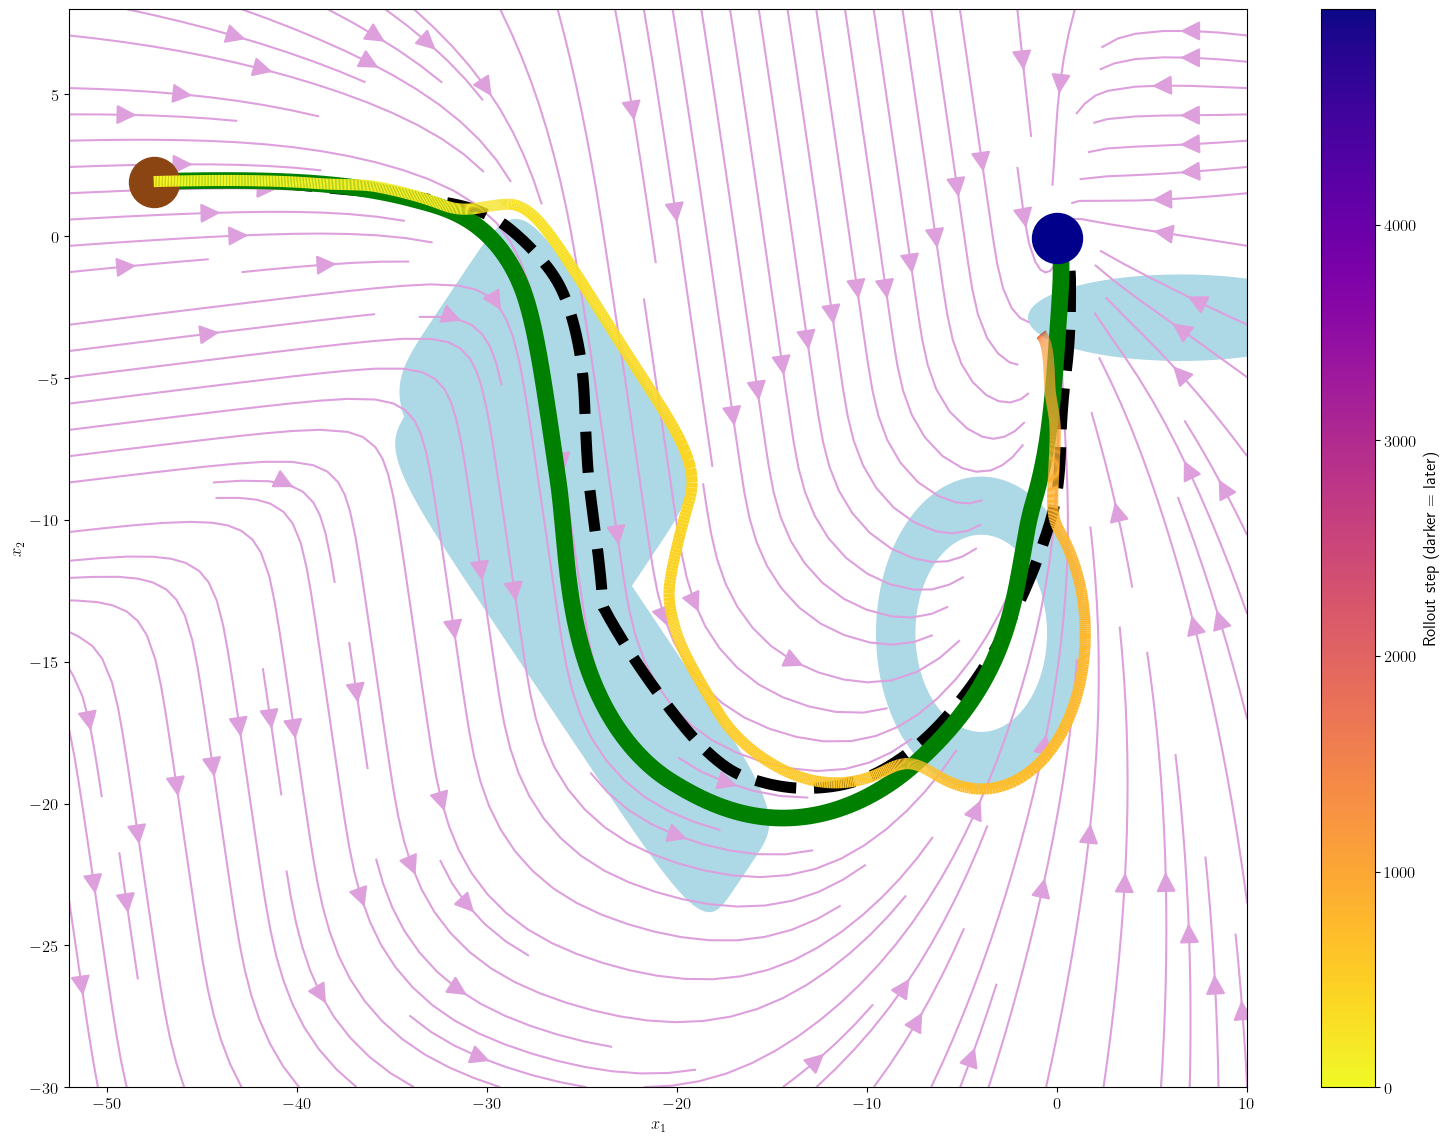

In [17]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

def streamQuiver(ax,sp,*args,spacing=None,n=5,**kwargs):
    """ Plot arrows from streamplot data
    The number of arrows per streamline is controlled either by `spacing` or by `n`.
    See `lines_to_arrows`.
    """
    def curve_coord(line=None):
        """ return curvilinear coordinate """
        x=line[:,0]
        y=line[:,1]
        s     = np.zeros(x.shape)
        s[1:] = np.sqrt((x[1:]-x[0:-1])**2+ (y[1:]-y[0:-1])**2)
        s     = np.cumsum(s)
        return s

    def curve_extract(line,spacing,offset=None):
        """ Extract points at equidistant space along a curve"""
        x=line[:,0]
        y=line[:,1]
        if offset is None:
            offset=spacing/2
        # Computing curvilinear length
        s = curve_coord(line)
        offset=np.mod(offset,s[-1]) # making sure we always get one point
        # New (equidistant) curvilinear coordinate
        sExtract=np.arange(offset,s[-1],spacing)
        # Interpolating based on new curvilinear coordinate
        xx=np.interp(sExtract,s,x);
        yy=np.interp(sExtract,s,y);
        return np.array([xx,yy]).T

    def seg_to_lines(seg):
        """ Convert a list of segments to a list of lines """
        def extract_continuous(i):
            x=[]
            y=[]
            # Special case, we have only 1 segment remaining:
            if i==len(seg)-1:
                x.append(seg[i][0,0])
                y.append(seg[i][0,1])
                x.append(seg[i][1,0])
                y.append(seg[i][1,1])
                return i,x,y
            # Looping on continuous segment
            while i<len(seg)-1:
                # Adding our start point
                x.append(seg[i][0,0])
                y.append(seg[i][0,1])
                # Checking whether next segment continues our line
                Continuous= all(seg[i][1,:]==seg[i+1][0,:])
                if not Continuous:
                    # We add our end point then
                    x.append(seg[i][1,0])
                    y.append(seg[i][1,1])
                    break
                elif i==len(seg)-2:
                    # we add the last segment
                    x.append(seg[i+1][0,0])
                    y.append(seg[i+1][0,1])
                    x.append(seg[i+1][1,0])
                    y.append(seg[i+1][1,1])
                i=i+1
            return i,x,y
        lines=[]
        i=0
        while i<len(seg):
            iEnd,x,y=extract_continuous(i)
            lines.append(np.array( [x,y] ).T)
            i=iEnd+1
        return lines

    def lines_to_arrows(lines,n=5,spacing=None,normalize=True):
        """ Extract "streamlines" arrows from a set of lines
        Either: `n` arrows per line
            or an arrow every `spacing` distance
        If `normalize` is true, the arrows have a unit length
        """
        if spacing is None:
            # if n is provided we estimate the spacing based on each curve lenght)
            spacing = [ curve_coord(l)[-1]/n for l in lines]
        try:
            len(spacing)
        except:
            spacing=[spacing]*len(lines)

        lines_s=[curve_extract(l,spacing=sp,offset=sp/2)         for l,sp in zip(lines,spacing)]
        lines_e=[curve_extract(l,spacing=sp,offset=sp/2+0.01*sp) for l,sp in zip(lines,spacing)]
        arrow_x  = [l[i,0] for l in lines_s for i in range(len(l))]
        arrow_y  = [l[i,1] for l in lines_s for i in range(len(l))]
        arrow_dx = [le[i,0]-ls[i,0] for ls,le in zip(lines_s,lines_e) for i in range(len(ls))]
        arrow_dy = [le[i,1]-ls[i,1] for ls,le in zip(lines_s,lines_e) for i in range(len(ls))]

        if normalize:
            dn = [ np.sqrt(ddx**2 + ddy**2) for ddx,ddy in zip(arrow_dx,arrow_dy)]
            arrow_dx = [ddx/ddn for ddx,ddn in zip(arrow_dx,dn)]
            arrow_dy = [ddy/ddn for ddy,ddn in zip(arrow_dy,dn)]
        return  arrow_x,arrow_y,arrow_dx,arrow_dy

    # --- Main body of streamQuiver
    # Extracting lines
    seg   = sp.lines.get_segments() # list of (2, 2) numpy arrays
    lines = seg_to_lines(seg)       # list of (N,2) numpy arrays
    # Convert lines to arrows
    ar_x, ar_y, ar_dx, ar_dy = lines_to_arrows(lines,spacing=spacing,n=n,normalize=True)
    # Plot arrows
    qv=ax.quiver(ar_x, ar_y, ar_dx, ar_dy, *args, angles='xy', **kwargs)
    return qv

## Worm
# xmin = -60
# xmax = 5
# ymin = -7
# ymax = 20

## Spoon
xmin = -52
xmax = 10
ymin = -30
ymax = 8

## Sine
# xmin = -60
# xmax = 10
# ymin = -20
# ymax = 30

indx = train_indx

f = lambda z : model.func(_, z, _)

(fig, ax) = plt.subplots(nrows=1, ncols=1, figsize=(19,14))
x, y = np.meshgrid(np.linspace(xmin, xmax, 50),
                   np.linspace(ymin, ymax, 50))
xy_vec = np.hstack((x.reshape((x.size, -1)), y.reshape((y.size, -1))))
uv_vec = jax.vmap(f, in_axes=0)(xy_vec)
proj_uv = uv_vec
u = np.asarray(proj_uv[:, 0]).reshape(x.shape)
v = np.asarray(proj_uv[:, 1]).reshape(y.shape)
sp = ax.streamplot(x, y, u ,v, arrowsize = 3, density=1.4, color='plum') #, arrowstyle='->', density=1, arrowsize=0.1)
# streamQuiver(ax, sp, n=10, color='plum', width = 0.01)
# fig = go.Figure()
model_y = model(ts, ys[indx, 0])
g_indx = -1
# ax.annotate('Start', xy=(model_y[0, 0], model_y[0, 1]), xytext=(-50, 25), textcoords='offset points', bbox=dict(boxstyle="round", fc="0.9", alpha=0.6))
# ax.annotate('Goal', xy=(model_y[g_indx, 0], model_y[g_indx, 1]), xytext=(-30, 0), textcoords='offset points', horizontalalignment='right', bbox=dict(boxstyle="round", fc="0.9", alpha=0.6))
## Switch mode
ax.plot(posn[indx, :, 0], posn[indx, :, 1], c="black", linestyle='--', linewidth='8', label="Demonstration")
ax.plot(model_y[:, 0], model_y[:, 1], c="green", linewidth='12', label="Target trajectory")
# model_y_1 = model(ts, posn[indx, 0])
# ax.plot(model_y_1[ :, 0], model_y_1[ :, 1], c="green", linewidth='3')
# switch_indx = 2
# model_y_2 = model(ts, posn[switch_indx, 0])
# ax.plot(model_y_2[ :, 0], model_y_2[ :, 1], c="green", linewidth='3')
# ax.plot(posn[switch_indx, :, 0], posn[switch_indx, :, 1], c="black", linestyle='--', linewidth='3')
# # ax.annotate('Switch mode', xy=(dist_point[0], dist_point[1]), xytext=(-10, -30), textcoords='offset points', horizontalalignment='right', bbox=dict(boxstyle="round", fc="0.9", alpha=0.6))
# ax.annotate("", xy=(dist_point[0], dist_point[1]), xytext=(model_y[dist_indx, 0], model_y[dist_indx, 1]),
#             arrowprops=dict(mutation_scale=30, arrowstyle="->", linewidth=3)) # Arrow


# Motion plan (real path) colored by rollout step (darker = later)
from matplotlib.collections import LineCollection
_path = np.asarray(xall)
_steps = np.arange(len(_path))
_pts = _path.reshape(-1, 1, 2)
_segs = np.concatenate([_pts[:-1], _pts[1:]], axis=1)
_lc = LineCollection(_segs, cmap='plasma_r', linewidth=8, label="Motion plan", zorder=3)
_lc.set_array(_steps[:-1])
ax.add_collection(_lc)
_cbar = fig.colorbar(_lc, ax=ax)
_cbar.set_label('Rollout step (darker = later)')

ax.plot(model_y[0, 0], model_y[0, 1], marker="o", markersize=36, c="saddlebrown")
ax.plot(model_y[-1, 0], model_y[-1, 1], marker="o", markersize=36, c="darkblue")

# Square obstacle boundaries (smooth superellipse)
def square_xy(xc, yc, a, b, angle, p=p_sq, n=300):
    th = np.linspace(0, 2*np.pi, n)
    cp = np.sign(np.cos(th)) * np.abs(np.cos(th))**(2.0/p)
    sp = np.sign(np.sin(th)) * np.abs(np.sin(th))**(2.0/p)
    ta, tb = a*cp, b*sp
    xs = xc + np.cos(angle)*ta + np.sin(angle)*tb
    ys = yc - np.sin(angle)*ta + np.cos(angle)*tb
    return xs, ys

x1, y1 = square_xy(center1[0], center1[1], semi_major_axis1, semi_minor_axis1, angle1)
x2, y2 = square_xy(center2[0], center2[1], semi_major_axis2, semi_minor_axis2, angle2)

# Full ring (annulus) obstacle
_th = np.linspace(0, 2*np.pi, 180)
_cx, _cy = float(np.asarray(c)[0]), float(np.asarray(c)[1])
_xo = _cx + r_out*np.cos(_th); _yo = _cy + r_out*np.sin(_th)
_xi = _cx + r_in*np.cos(_th[::-1]); _yi = _cy + r_in*np.sin(_th[::-1])
ax.fill(np.concatenate([_xo, _xi]), np.concatenate([_yo, _yi]), color='lightblue', alpha=1)

# Ellipse obstacle (thin & long) below target, top tangent to (0,0)
_te = np.linspace(0, 2*np.pi, 200)
ax.fill(xe + ae*np.cos(_te), ye + be*np.sin(_te), color='lightblue', alpha=1)

# Plot the ellipses
# plt.figure()
# plt.plot(x1, y1, color='lightblue')
ax.fill(x1, y1, color='lightblue', alpha=1)  # Fill with color
# #plt.plot(x2, y2, color='lightblue')
ax.fill(x2, y2, color='lightblue', alpha=1)  # Fill with color


# model_y_dist = model_load(ts, dist_point)
# ax.plot(model_y_dist[:, 0], model_y_dist[:, 1], c="crimson", linewidth='3')

## Obstacle
# xc = c
# circle = plt.Circle((xc), r, color='dodgerblue', fill=1, alpha=0.5, label="Obstacle")
# ax.add_artist(circle)

# # ax.plot(model_y_dist[:, 0], model_y_dist[:, 1], c="red", linewidth='4', label="Without correction", linestyle='--')
# ax.plot(xall[:, 0], xall[:, 1], c="red", linewidth='4')
# ax.plot(model_y[:dist_indx, 0], model_y[:dist_indx, 1], c="red", linewidth='4', linestyle='--', label="Robot's path")
# plt.plot(np.array([model_y[130, 0], model_y_dist[0, 0]]), np.array([model_y[130, 1], model_y_dist[0, 1]]), c="green", linewidth='2', label="Disturbance", linestyle='--')
# plt.arrow(model_y[130, 0], model_y[130, 1], model_y_dist[0, 0] - model_y[130, 0], model_y_dist[0, 1] - model_y[130, 1])
## Disturbance
# ax.annotate('Disturbance', xy=(dist_point[0], dist_point[1]), xytext=(-10, 15), textcoords='offset points', horizontalalignment='right', bbox=dict(boxstyle="round", fc="0.9", alpha=0.6))
# ax.annotate("", xy=(dist_point[0], dist_point[1]), xytext=(model_y[dist_indx, 0], model_y[dist_indx, 1]), arrowprops=dict(mutation_scale=30, arrowstyle="->", linewidth=3)) # Arrow

# alpha = 7
# alpha_n = 12
# ax.plot(model_y[dist_indx, 0], model_y[dist_indx, 1], marker="o", markersize=18, c="black")
# ax.plot(dist_point[0], dist_point[1], marker="o", markersize=24, c="black")
# plt.plot(traj_all_process[indx, 0, 0], traj_all_process[indx, 0, 1], 'ro')
# plt.plot(traj_all_process[indx, -1, 0], traj_all_process[indx, -1, 1], 'go')
# ax.plot(ys[indx, :, 0], ys[indx, :, 1], ys[indx, :, 2], c='red', label='Demonstration')
# ax.legend(loc='lower left')
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_xlim([float(xmin), float(xmax)])
ax.set_ylim([float(ymin), float(ymax)])
# ax.set_xlabel('x')
# plt.tight_layout()
plt.show()

Model parameters:

Line:

lr_strategy=(3e-3,),
steps_strategy=(5000,),
length_strategy=(1,),
width_size=32,
depth=3,

Saeghe:

lr_strategy=(3e-4,),
steps_strategy=(8000,),
length_strategy=(1,),
width_size=128,
depth=3,

BendedLine(okayish), Zshape, Worm:

lr_strategy=(4e-4,),
steps_strategy=(7000,),
length_strategy=(1,),
width_size=64,
depth=3,

Trapezoid, Sine, Wshape(bad):

lr_strategy=(3e-4,),
steps_strategy=(8000,),
length_strategy=(1,),
width_size=128,
depth=3,

Angle:

lr_strategy=(4e-4,),
steps_strategy=(8000,),
length_strategy=(1,),
width_size=128,
depth=3,

Leaf_1:

lr_strategy=(3e-4,),
steps_strategy=(8000,),
length_strategy=(1,),
width_size=128,
depth=5,

L/J2/J/GShape:

lr_strategy=(6e-4,),
steps_strategy=(7000,),
length_strategy=(1,),
width_size=64,
depth=3,

RShape, PShape:

lr_strategy=(6e-4,),
steps_strategy=(8000,),
length_strategy=(1,),
width_size=64,
depth=3,

Sshape, Snake, Sharpc:

lr_strategy=(4e-4,),
steps_strategy=(7000,),
length_strategy=(1,),
width_size=64,
depth=3,

Multi_Models_1, 3, 4:

lr_strategy=(6e-4,),
steps_strategy=(8000,),
length_strategy=(1,),
width_size=128,
depth=3,

Leaf_2: width_size = 128

Khmahesh(bad), Hee:

lr_strategy=(2e-4,),
steps_strategy=(7000,),
length_strategy=(1,),
width_size=128,
depth=3,

Multi_Models_2, DoubleBendedLine, CShape, Spoon, NShape:

lr_strategy=(9e-4,),
steps_strategy=(7000,),
length_strategy=(1,),
width_size=64,
depth=3,